# Severity agreement of CNN segmentation vs ASSESS 2.0 — reproduction of the concordance analysis

**Paper:** *Deep learning models for semantic segmentation and automatic estimation of severity of foliar symptoms caused by diseases or pests* — OSF preprint [doi:10.31219/osf.io/wdb79](https://doi.org/10.31219/osf.io/wdb79) (wdb79_v1, 2020-07-09); published version [doi:10.1016/j.biosystemseng.2021.08.011](https://doi.org/10.1016/j.biosystemseng.2021.08.011).

**Author code:** [emdelponte/paper-semantic-segmentation-severity](https://github.com/emdelponte/paper-semantic-segmentation-severity) @ commit `9b8402943839df7f54c8cea27ca7f72500574780` (`index.Rmd` + per-model CSVs).

**Scope of this notebook (exact):** reproduce the paper's **severity-agreement subsection** — for each CNN model (FPN, U-Net, SegNet, PSPNet, DeepLabv3+ Xception, DeepLabv3+ MobileNetV2) and ASSESS 2.0, compute Lin's concordance correlation coefficient (ρc), bias factor Cb, Pearson r, scale/location shifts, RMSE against reference severity, and draw the predicted-vs-reference plots for coffee leaf miner, soybean rust, and wheat tan spot test images. The segmentation training/evaluation stage is **out of scope**: no raw images, masks, or trained weights are published for that stage.

**Execution status:** executed CPU-only Colab notebook (R via `Rscript`; no GPU needed). Expected runtime ≈ 3–5 minutes, downloads ≈ 100 KB.

**概要:** 本ノートブックは上記論文の「重症度一致度解析」の節を最小構成で再現します。著者の `index.Rmd` とモデル別 CSV をピン留したコミットから取得し、Lin の concordance correlation coefficient (ρc)・Cb・r・スケール/位置シフト・RMSE を計算し、作物別の予測vs参照散布図を作成します。セグメンテーションの学習・評価は対象外です（画像・マスク・重みは未公開のため）。

**AI-assisted adaptation notice / AI改変の明示:**
The delivered R script is an **AI-assisted reimplementation** of the author's `epiR::epi.ccc` computation: Lin's (1989) concordance coefficient, Cb = ρc/r, scale shift σx/σy, and location shift (μx−μy)/√(σxσy) are computed with the exact closed-form definitions, plus RMSE. We avoid installing `epiR` because its dependency chain takes ~18 min to compile in Colab (measured). All 21 computed ρc values are validated against the author's own published reference values (`all_ccc` table embedded in `index.Rmd`); the notebook fails loudly if any differs by more than 0.015. Plots replicate the author's colors, 1:1 line, and lm smooth with preinstalled ggplot2 (`facet_wrap` instead of `patchwork`, `theme_minimal()` instead of `ggthemes::theme_minimal_grid`). The author did not provide this Colab implementation; untested behavior is not guaranteed. / 上記はAIによる再実装であり、著者提供のColab実装ではありません。算出したρcは著者公開の参照値と全件照合されます。

## Runtime selection

This is a pure R statistics workload (21 regressions/CCC computations on ~1100 rows): **CPU only**. No GPU is required or useful — do not request one. The notebook uses the standard Colab CPU runtime and calls the preinstalled `Rscript` (verified: R 4.6.1 on the standard CPU image) from short Python orchestration cells; Python is only the launcher, all analysis is the R code shown in the cells.

**実行環境:** CPU ランタイムのみで実行します（R の統計計算のみで GPU 不要）。Python セルはランチャーであり、解析はすべて R (`Rscript`) で実行されます。

### Environment check

The next cell verifies that `Rscript` and the preinstalled ggplot2/dplyr stack are available and prints their versions; if `Rscript` were missing it attempts an apt install as a documented fallback (on current standard CPU runtimes R is preinstalled, so this is a no-op).

**期待結果:** R 4.6.x と ggplot2 のバージョンが表示されます。

In [ ]:
import shutil, subprocess
from pathlib import Path

rscript = shutil.which("Rscript") or "/usr/bin/Rscript"
if not Path(rscript).exists():
    subprocess.run(["apt-get", "update", "-qq"], check=True)
    subprocess.run(["apt-get", "install", "-y", "-qq", "r-base-core"], check=True)
    rscript = shutil.which("Rscript")
print("Rscript:", rscript)
r = subprocess.run([rscript, "-e",
    'cat(R.version.string, "\n"); cat("ggplot2", as.character(packageVersion("ggplot2")), "\n")'],
    capture_output=True, text=True, timeout=300, check=True)
print(r.stdout)

Rscript: /usr/bin/Rscript


R version 4.6.1 (2026-06-24) 
ggplot2 4.0.3 



### Download the author's pinned data files

Downloads the 7 per-model severity CSVs used by `index.Rmd` (plus `index.Rmd` itself and the unused `LinkNet.csv` for reference) from the pinned commit `9b8402943839df7f54c8cea27ca7f72500574780` via raw.githubusercontent.com, then verifies every file's **git blob SHA-1** against the pinned repository tree (blob hashes from `git/trees?recursive=1` at that commit). Mismatch aborts the notebook.

**期待結果:** 9 ファイルのダウンロードと blob SHA-1 の全件一致 (OK) が表示されます。

In [ ]:
import hashlib, urllib.request
from pathlib import Path

COMMIT = "9b8402943839df7f54c8cea27ca7f72500574780"
REPO = "emdelponte/paper-semantic-segmentation-severity"
DATA = Path("/content/data"); DATA.mkdir(parents=True, exist_ok=True)
FILES = {
    "index.Rmd": "4822e6456d1b7626b47cee0c4f09a9a2d24e772f",
    "fpn.csv": "c8c1bd8916f7a6bf51e9d533222fc2ff9997ade3",
    "mobilenetv2.csv": "973e0f3e7a445225e46085824a8d3e44e5e296ac",
    "PSPNet.csv": "4154f84bce72560fac2be3d95eb3995ba82c3ec9",
    "Segnet.csv": "35a6be336351b66b899cc3f9726c75fe42ae6ca5",
    "Unet.csv": "2317ece58e5cb18990ecddc3e54b5c687cf44e03",
    "xception.csv": "f2f36ee52ee9ddac9f3834ed3ee8652ded332bb0",
    "Assess.csv": "17d7a0808b8befbe8478b0d78e3f87392263c5d7",
    "LinkNet.csv": "e125b3710028281eb95d49df306d0ccf6ff16cfb",
}

def blob_sha1(path):
    data = path.read_bytes()
    h = hashlib.sha1()
    h.update(f"blob {len(data)}\0".encode()); h.update(data)
    return h.hexdigest()

for name, expected in FILES.items():
    dest = DATA / name
    urllib.request.urlretrieve(f"https://raw.githubusercontent.com/{REPO}/{COMMIT}/{name}", dest)
    got = blob_sha1(dest)
    status = "OK" if got == expected else "MISMATCH"
    print(f"{name:18s} {len(dest.read_bytes()):7d} B  blob {got[:12]}...  {status}")
    assert got == expected, f"blob SHA mismatch for {name}: {got} != {expected}"
print("All pinned blob hashes verified.")

index.Rmd            22508 B  blob 4822e6456d1b...  OK
fpn.csv               3503 B  blob c8c1bd8916f7...  OK


mobilenetv2.csv       3850 B  blob 973e0f3e7a44...  OK
PSPNet.csv            3822 B  blob 4154f84bce72...  OK


Segnet.csv            3726 B  blob 35a6be336351...  OK
Unet.csv              3836 B  blob 2317ece58e5c...  OK


xception.csv          3714 B  blob f2f36ee52ee9...  OK
Assess.csv            3884 B  blob 17d7a0808b8b...  OK


LinkNet.csv           4004 B  blob e125b3710028...  OK
All pinned blob hashes verified.


### Combine the data exactly as `index.Rmd` does

The first author chunk reads the seven CSVs, adds the model label (`fpn.csv`→FPN, `mobilenetv2.csv`→DeeplabV3M, `xception.csv`→DeeplabV3X, …, `Assess.csv`→Assess), and binds them (`LinkNet.csv` exists in the repository but is **not** used by `index.Rmd`). `actual`/`predicted` are severity percentages (0–100; coffee leaf miner mostly < 23%). This cell re-creates that combined table in R, saves it for later cells, and previews the data: row counts per image set and model, value ranges, and the first rows.

**期待結果:** 約1080行の結合テーブル、image_set/model 別行数、actual/predicted の範囲（%重症度）、先頭行が表示されます。

In [ ]:
R_COMBINE = r'''
# Combine the author's CSVs exactly as index.Rmd does and save for the plot cells.
files <- data.frame(
  file  = c("fpn.csv", "mobilenetv2.csv", "PSPNet.csv", "Segnet.csv",
            "Unet.csv", "xception.csv", "Assess.csv"),
  model = c("FPN", "DeeplabV3M", "PSPNet", "Segnet", "Unet", "DeeplabV3X", "Assess"))
dat <- do.call(rbind, lapply(seq_len(nrow(files)), function(i) {
  d <- read.csv(file.path("/content/data", files$file[i]), stringsAsFactors = FALSE)
  d$model <- files$model[i]
  d$actual2 <- as.numeric(d$actual)
  d$predicted2 <- as.numeric(d$predicted)
  d
}))
cat("combined rows:", nrow(dat), "\n")
cat("rows per image_set:\n"); print(table(dat$image_set))
cat("rows per model:\n"); print(table(dat$model))
cat("actual range: ", range(dat$actual2, na.rm = TRUE), "\n")
cat("predicted range: ", range(dat$predicted2, na.rm = TRUE), "\n")
cat("NA actual: ", sum(is.na(as.numeric(dat$actual))),
    "; NA predicted: ", sum(is.na(as.numeric(dat$predicted))), "\n")
dir.create("/content/data", showWarnings = FALSE, recursive = TRUE)
saveRDS(dat, "/content/data/combined.rds")
'''
Path("/content/severity_combine.R").write_text(R_COMBINE)
r = subprocess.run(["Rscript", "/content/severity_combine.R"],
                   capture_output=True, text=True, timeout=300, check=True)
print(r.stdout)
r2 = subprocess.run(["Rscript", "-e",
    'd <- readRDS("/content/data/combined.rds"); print(head(d[, c("image_set","model","actual2","predicted2")], 8))'],
    capture_output=True, text=True, timeout=300, check=True)
print(r2.stdout)

combined rows: 1077 
rows per image_set:

 coffee_miner  soybean_rust wheat_tanspot 
          567           294           216 
rows per model:

    Assess DeeplabV3M DeeplabV3X        FPN     PSPNet     Segnet       Unet 
       155        154        154        152        154        154        154 
actual range:  0.06 95.43 
predicted range:  0 97.806 
NA actual:  0 ; NA predicted:  0 



     image_set model actual2 predicted2
1 coffee_miner   FPN    4.49       4.99
2 coffee_miner   FPN    2.78       3.49
3 coffee_miner   FPN    5.85       6.55
4 coffee_miner   FPN    3.11       2.41
5 coffee_miner   FPN    3.27       3.01
6 coffee_miner   FPN    5.71       7.18
7 coffee_miner   FPN    8.04       8.26
8 coffee_miner   FPN    6.76       7.22



### Core method: Lin's concordance coefficient, bias/scale/location shifts, RMSE (pinned R source)

Writes `/content/severity_analysis.R` — a readable, pinned R script that: (1) loads the combined data; (2) computes Lin's ρc = 2·s_xy/(s_x²+s_y²+(μx−μy)²), Cb = ρc/r, scale shift σx/σy, location shift (μx−μy)/√(σxσy) — the same quantities `epiR::epi.ccc` reports — plus RMSE = √mean((predicted−actual)²) for every model × image set; (3) adds fixed-seed (42, B=2000) percentile bootstrap 95% CIs (the author's `epi.ccc` also uses bootstrap CIs; our seed/B differ, so CIs will differ slightly while point estimates are seed-free); (4) compares all 21 ρc values against the author's published `all_ccc` values embedded in `index.Rmd` and **stops with an error if any |difference| ≥ 0.015**; (5) writes `outputs/severity_ccc_results.csv`.

**期待結果:** 21 行の結果テーブル（rho, 95%CI, Cb, r, s.shift, l.shift, RMSE, 著者参照値との差）と、最大差の表示（< 0.015 で OK）。

In [ ]:
R_ANALYSIS = r'''
# Severity-agreement analysis, reproduced from index.Rmd (commit 9b840294)
# Author's original code uses epiR::epi.ccc; this script implements Lin's
# (1989) concordance coefficient with the same reported quantities
# (rho, C.b, scale shift, location shift) plus RMSE, and validates the
# point estimates against the author's published all_ccc table.

DATA_DIR <- "/content/data"
OUT_DIR  <- "/content/outputs"
dir.create(OUT_DIR, showWarnings = FALSE, recursive = TRUE)

## ---- Load and combine the author's per-model CSVs (chunk "Combine all data") ----
files <- data.frame(
  file  = c("fpn.csv", "mobilenetv2.csv", "PSPNet.csv", "Segnet.csv",
            "Unet.csv", "xception.csv", "Assess.csv"),
  model = c("FPN", "DeeplabV3M", "PSPNet", "Segnet", "Unet", "DeeplabV3X", "Assess"))
dat <- do.call(rbind, lapply(seq_len(nrow(files)), function(i) {
  d <- read.csv(file.path(DATA_DIR, files$file[i]), stringsAsFactors = FALSE)
  d$model <- files$model[i]
  d$actual2 <- as.numeric(d$actual)      # reference severity (%)
  d$predicted2 <- as.numeric(d$predicted) # predicted severity (%)
  d
}))
dat <- dat[complete.cases(dat[, c("actual2", "predicted2")]), ]
cat("combined rows:", nrow(dat), "\n")

## ---- Lin's concordance correlation coefficient (Lin 1989), following epi.ccc ----
ccc_point <- function(x, y) {
  sx <- sd(x); sy <- sd(y); sxy <- cov(x, y)
  mx <- mean(x); my <- mean(y)
  rho <- 2 * sxy / (sx^2 + sy^2 + (mx - my)^2)  # Lin's rho_c
  r <- sxy / (sx * sy)                          # Pearson r
  cb <- rho / r                                 # bias correction factor C.b
  data.frame(rho = rho, c.b = cb, r = r,
             s.shift = sx / sy,                 # scale shift (nu)
             l.shift = (mx - my) / sqrt(sx * sy)) # location shift (mu)
}
ccc_boot_ci <- function(x, y, B = 2000, seed = 42) {
  set.seed(seed); n <- length(x)
  stats <- replicate(B, {
    idx <- sample.int(n, n, replace = TRUE)
    ccc_point(x[idx], y[idx])$rho })
  quantile(stats, c(0.025, 0.975), names = FALSE)
}
rmse <- function(x, y) sqrt(mean((y - x)^2))

## ---- Author's published reference values (all_ccc tribble in index.Rmd) ----
all_ccc <- data.frame(
  crop   = c(rep("coffee_miner", 7), rep("soybean_rust", 7), rep("wheat_tanspot", 7)),
  model  = c("Unet", "FPN", "DeeplabV3X", "Segnet", "DeeplabV3M", "PSPNet", "Assess",
             "Unet", "FPN", "DeeplabV3X", "Segnet", "DeeplabV3M", "PSPNet", "Assess",
             "Unet", "FPN", "DeeplabV3X", "Segnet", "DeeplabV3M", "PSPNet", "Assess"),
  value  = c(0.983, 0.979, 0.969, 0.948, 0.940, 0.820, 0.938,
             0.967, 0.967, 0.965, 0.936, 0.938, 0.933, 0.957,
             0.982, 0.983, 0.983, 0.977, 0.955, 0.980, 0.969),
  lower  = c(0.973, 0.968, 0.954, 0.920, 0.911, 0.748, 0.908,
             0.943, 0.942, 0.942, 0.900, 0.900, 0.893, 0.922,
             0.964, 0.964, 0.966, 0.955, 0.917, 0.960, 0.939),
  upper  = c(0.989, 0.986, 0.980, 0.966, 0.959, 0.873, 0.959,
             0.981, 0.981, 0.979, 0.959, 0.962, 0.958, 0.976,
             0.991, 0.991, 0.991, 0.989, 0.976, 0.990, 0.985))

## ---- Compute per model x crop ----
results <- do.call(rbind, lapply(split(dat, list(dat$image_set, dat$model)), function(d) {
  x <- d$actual2; y <- d$predicted2
  est <- ccc_point(x, y)
  ci <- ccc_boot_ci(x, y)
  data.frame(image_set = d$image_set[1], model = d$model[1], n = nrow(d),
             rho = est$rho, lower = ci[1], upper = ci[2],
             c.b = est$c.b, r = est$r, s.shift = est$s.shift,
             l.shift = est$l.shift, rmse = rmse(x, y))
}))
results <- results[order(results$image_set, results$model), ]
ref <- all_ccc[match(paste(results$image_set, results$model),
                     paste(all_ccc$crop, all_ccc$model)), ]
results$ref_rho <- ref$value
results$rho_diff <- results$rho - results$ref_rho
print(results, digits = 3)
cat("max |computed rho_c - author published rho_c| =", max(abs(results$rho_diff)), "\n")
stopifnot(max(abs(results$rho_diff)) < 0.015)
write.csv(results, file.path(OUT_DIR, "severity_ccc_results.csv"), row.names = FALSE)
saveRDS(results, file.path(OUT_DIR, "results.rds"))
cat("OK\n")
'''
Path("/content/severity_analysis.R").write_text(R_ANALYSIS)
import time
t0 = time.time()
r = subprocess.run(["Rscript", "/content/severity_analysis.R"],
                   capture_output=True, text=True, timeout=1800)
print(r.stdout)
if r.returncode != 0:
    print(r.stderr)
    raise RuntimeError(f"severity_analysis.R failed with exit {r.returncode}")
print(f"analysis elapsed {time.time()-t0:.1f} s")

combined rows: 1077 
                             image_set      model  n   rho lower upper   c.b
coffee_miner.Assess       coffee_miner     Assess 82 0.939 0.847 0.977 0.983
coffee_miner.DeeplabV3M   coffee_miner DeeplabV3M 81 0.940 0.897 0.966 0.976
coffee_miner.DeeplabV3X   coffee_miner DeeplabV3X 81 0.970 0.935 0.989 0.995
coffee_miner.FPN          coffee_miner        FPN 80 0.979 0.962 0.990 0.998
coffee_miner.PSPNet       coffee_miner     PSPNet 81 0.821 0.686 0.934 0.917
coffee_miner.Segnet       coffee_miner     Segnet 81 0.948 0.909 0.974 1.000
coffee_miner.Unet         coffee_miner       Unet 81 0.983 0.972 0.990 1.000
soybean_rust.Assess       soybean_rust     Assess 42 0.957 0.922 0.978 0.993
soybean_rust.DeeplabV3M   soybean_rust DeeplabV3M 42 0.939 0.901 0.964 0.970
soybean_rust.DeeplabV3X   soybean_rust DeeplabV3X 42 0.966 0.945 0.979 0.989
soybean_rust.FPN          soybean_rust        FPN 42 0.967 0.945 0.981 0.995
soybean_rust.PSPNet       soybean_rust     PSPNet 42 0.

### Result: combined concordance plot (recomputed vs author-published ρc)

Mirrors the author's `plot_all.png`/`assess_ccc.png` figure: ρc per method faceted by crop, with our recomputed ρc (filled dots) and bootstrap 95% CIs (error bars), overlaid with the author's published ρc (open circles). Filled and open markers overlapping confirms the recomputation against the paper's values.

**期待結果:** 作物別 3 パネルの ρc 比較図。塗りつぶし点（再計算、エラーバー付き）と白抜き点（著者公開値）がほぼ重なります。

saved



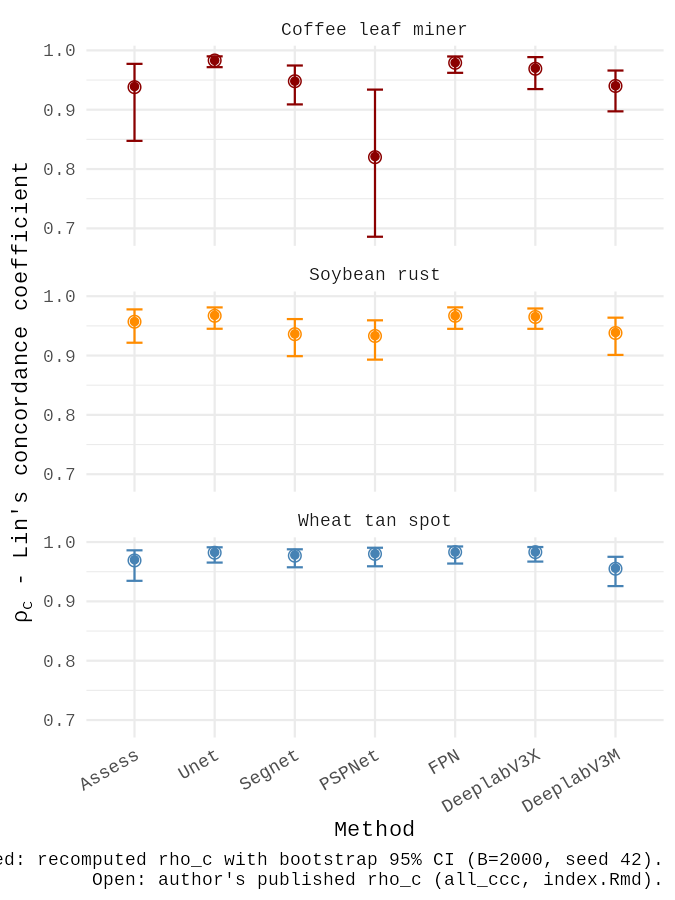

In [ ]:
R_PLOT = r'''
# Combined concordance plot: our computed rho_c with bootstrap CI,
# overlaid with the author's published rho_c (open circles), mirroring
# the author's plot_all.png / assess_ccc.png figure.
library(ggplot2)
results <- readRDS("/content/outputs/results.rds")
crop_label <- c(coffee_miner = "Coffee leaf miner", soybean_rust = "Soybean rust",
                wheat_tanspot = "Wheat tan spot")
results$crop_label <- unname(crop_label[results$image_set])
crop_order <- c("Coffee leaf miner", "Soybean rust", "Wheat tan spot")
results$crop_label <- factor(results$crop_label, levels = crop_order)
results$model <- factor(results$model,
  levels = c("Assess", "Unet", "Segnet", "PSPNet", "FPN", "DeeplabV3X", "DeeplabV3M"))
crop_colors <- c("Coffee leaf miner" = "darkred", "Soybean rust" = "darkorange",
                 "Wheat tan spot" = "steelblue")
p <- ggplot(results, aes(model, rho, color = crop_label)) +
  geom_point(data = transform(results, rho = ref_rho), shape = 1, size = 2.5) +
  geom_point() +
  geom_errorbar(aes(ymin = lower, ymax = upper), width = 0.2) +
  facet_wrap(~crop_label, ncol = 1) +
  scale_color_manual(values = crop_colors) +
  theme_minimal() +
  theme(legend.position = "none", axis.text.x = element_text(angle = 30, hjust = 1)) +
  labs(x = "Method", y = expression(rho[c]*" - Lin's concordance coefficient"),
       caption = "Filled: recomputed rho_c with bootstrap 95% CI (B=2000, seed 42).\nOpen: author's published rho_c (all_ccc, index.Rmd).")
dir.create("/content/outputs", showWarnings = FALSE, recursive = TRUE)
ggsave("/content/outputs/ccc_combined.png", p, width = 4.5, height = 6, dpi = 150)
cat("saved\n")
'''
Path("/content/severity_plot_ccc.R").write_text(R_PLOT)
r = subprocess.run(["Rscript", "/content/severity_plot_ccc.R"],
                   capture_output=True, text=True, timeout=600)
print(r.stdout)
if r.returncode != 0:
    print(r.stderr)
    raise RuntimeError("ccc plot failed")
from IPython.display import Image, display
display(Image(filename="/content/outputs/ccc_combined.png"))

### Predicted vs reference severity panels (the author's coffee/wheat/soybean figures)

Replicates the author's per-crop 6-panel figures (`coffee.png`, `wheat.png`, `soybean.png` in the repository): predicted severity against reference severity, crop colors (coffee darkred, soybean darkorange, wheat steelblue), the 1:1 line, the dashed lm fit, and the author's axis limits (coffee 0–23%, soybean/wheat 0–100%). `Assess` 2.0 appears as a seventh panel so CNNs can be compared with the commercial color-threshold software.

**期待結果:** 作物別パネル図 3 枚。FPN/U-Net/DeeLabv3+ (Xception) は 1:1 線上に密集し、PSPNet などは過大推価の傾向が見えます。

saved coffee.png 
saved soybean.png 
saved wheat.png 



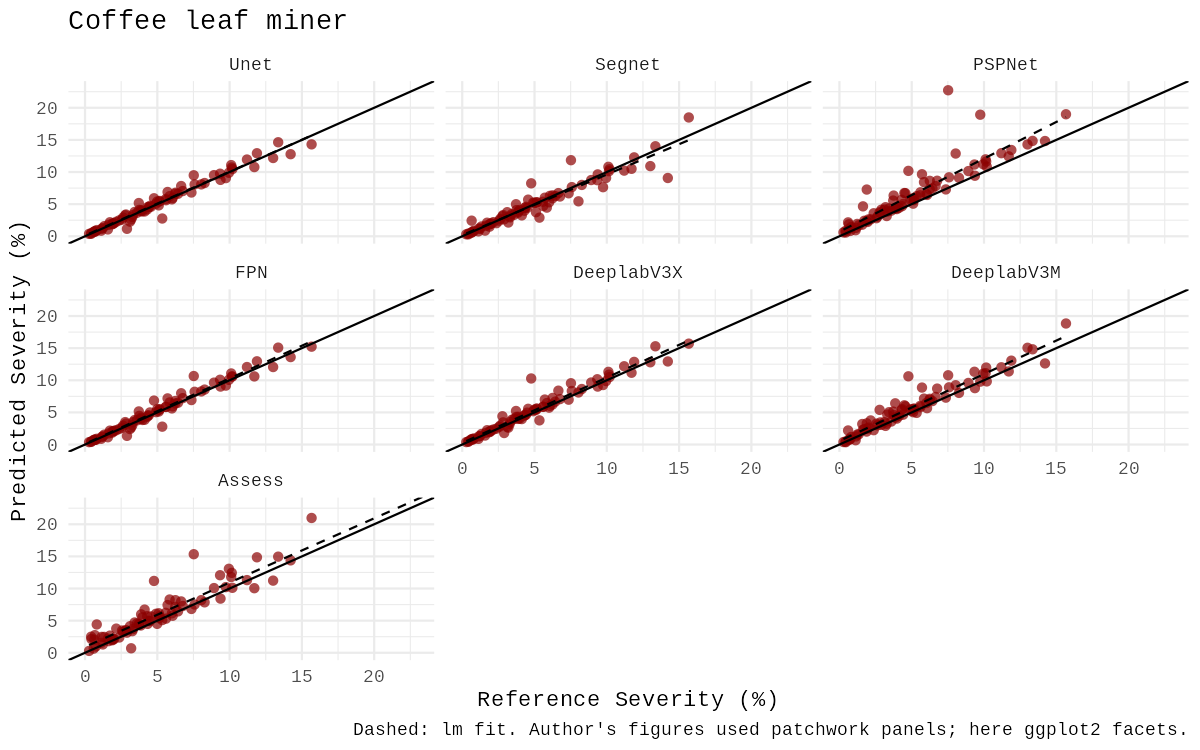

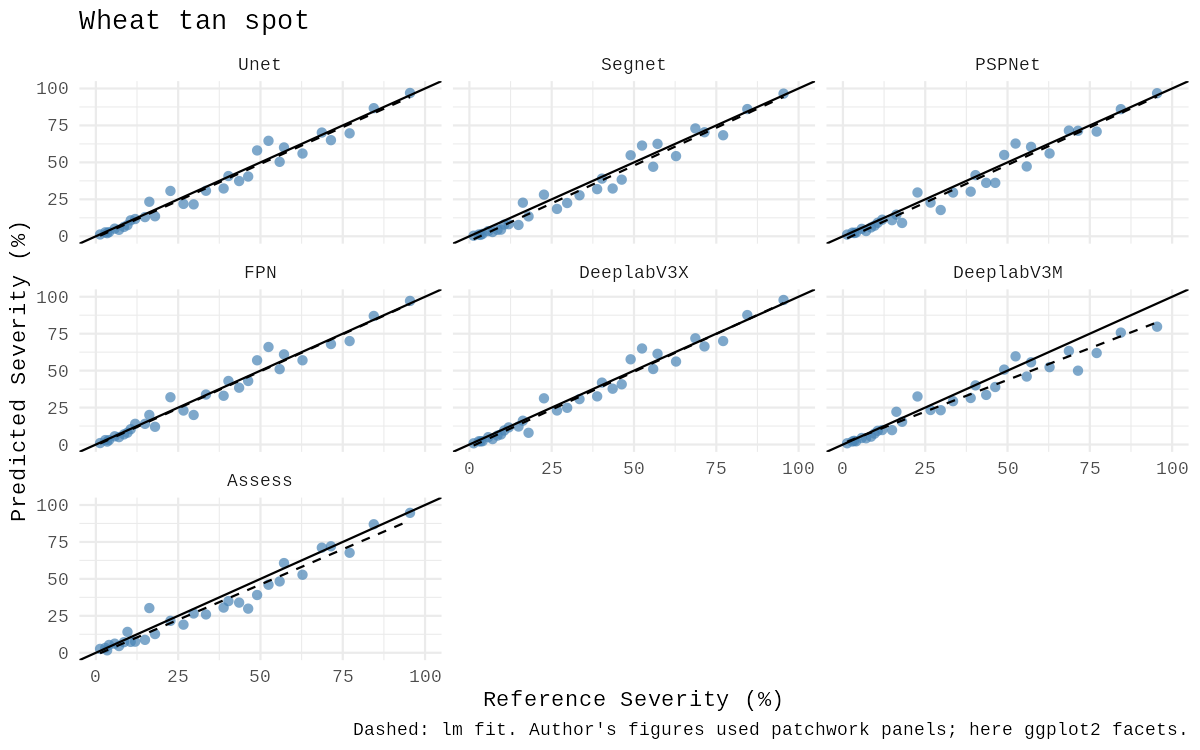

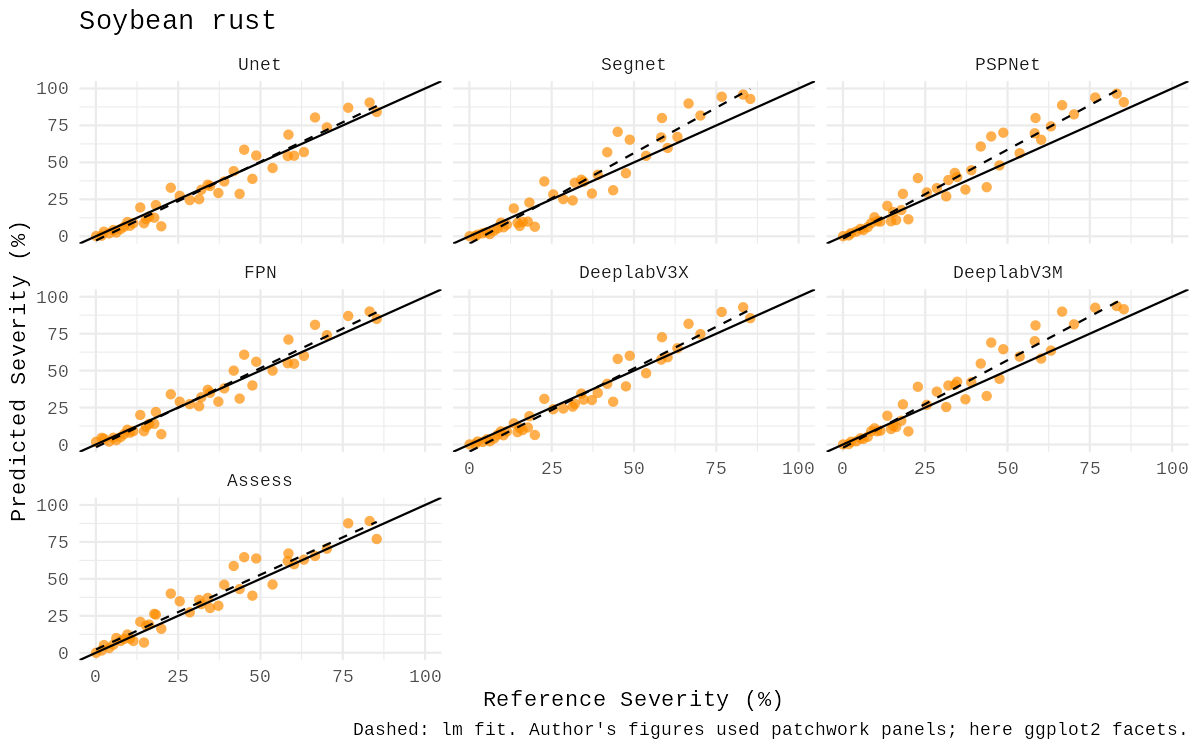

In [ ]:
R_PANELS = r'''
# Predicted vs reference severity panels per crop, replicating the
# author's coffee.png / wheat.png / soybean.png figures (colors, 1:1
# line, lm smooth, axis limits) with facet_wrap instead of patchwork.
library(ggplot2)
dat <- readRDS("/content/data/combined.rds")
specs <- list(
  list(set = "coffee_miner", color = "darkred", lim = 23,
       file = "coffee.png", title = "Coffee leaf miner"),
  list(set = "soybean_rust", color = "darkorange", lim = 100,
       file = "soybean.png", title = "Soybean rust"),
  list(set = "wheat_tanspot", color = "steelblue", lim = 100,
       file = "wheat.png", title = "Wheat tan spot"))
for (s in specs) {
  d <- dat[dat$image_set == s$set, ]
  d$model <- factor(d$model, levels = c("Unet", "Segnet", "PSPNet",
                                        "FPN", "DeeplabV3X", "DeeplabV3M", "Assess"))
  p <- ggplot(d[!is.na(d$model), ], aes(actual2, predicted2)) +
    geom_point(color = s$color, shape = 16, size = 2, alpha = 0.7) +
    geom_abline(intercept = 0, slope = 1, linewidth = 0.5) +
    geom_smooth(method = "lm", se = FALSE, color = "black", linetype = 2, linewidth = 0.5) +
    facet_wrap(~model, ncol = 3) +
    coord_cartesian(xlim = c(0, s$lim), ylim = c(0, s$lim)) +
    theme_minimal() +
    labs(x = "Reference Severity (%)", y = "Predicted Severity (%)",
         title = s$title,
         caption = "Dashed: lm fit. Author's figures used patchwork panels; here ggplot2 facets.")
  ggsave(file.path("/content/outputs", s$file), p, width = 8, height = 5, dpi = 150)
  cat("saved", s$file, "\n")
}
'''
Path("/content/severity_panels.R").write_text(R_PANELS)
r = subprocess.run(["Rscript", "/content/severity_panels.R"],
                   capture_output=True, text=True, timeout=900)
print(r.stdout)
if r.returncode != 0:
    print(r.stderr)
    raise RuntimeError("panel plots failed")
from IPython.display import Image, display
for f in ("coffee.png", "wheat.png", "soybean.png"):
    display(Image(filename=f"/content/outputs/{f}"))

### Export the results table

Writes the full per-model × crop table (n, ρc, bootstrap CI, Cb, r, scale/location shifts, RMSE, author reference ρc, difference) to `/content/outputs/severity_ccc_results.csv` for download, and shows it inline.

**期待結果:** CSV ファイルが保存され、表が表示されます。

In [ ]:
import pandas as pd
df = pd.read_csv("/content/outputs/severity_ccc_results.csv")
df.to_csv("severity_ccc_results.csv", index=False)
print(f"rows: {len(df)}; saved copy at ./severity_ccc_results.csv (also /content/outputs/)")
df

rows: 21; saved copy at ./severity_ccc_results.csv (also /content/outputs/)


,image_set,model,n,rho,lower,upper,c.b,r,s.shift,l.shift,rmse,ref_rho,rho_diff
0,coffee_miner,Assess,82,0.939111,0.847488,0.977276,0.982814,0.955533,0.955212,-0.181311,1.779295,0.938,0.001111
1,coffee_miner,DeeplabV3M,81,0.940399,0.897236,0.966021,0.976450,0.963080,0.925354,-0.205463,1.309749,0.940,0.000399
2,coffee_miner,DeeplabV3X,81,0.969948,0.934753,0.988651,0.994958,0.974864,0.958169,-0.091153,0.904249,0.969,0.000948
3,coffee_miner,FPN,80,0.979262,0.962152,0.989733,0.997947,0.981277,0.963174,-0.052028,0.752291,0.979,0.000262
4,coffee_miner,PSPNet,81,0.821056,0.685892,0.933867,0.917396,0.894984,0.786447,-0.349419,2.539211,0.820,0.001056
5,coffee_miner,Segnet,81,0.948116,0.908924,0.974492,0.999515,0.948577,1.005365,0.030702,1.156348,0.948,0.000116
6,coffee_miner,Unet,81,0.983067,0.971708,0.989923,0.999678,0.983384,0.989906,-0.023286,0.665713,0.983,0.000067
7,soybean_rust,Assess,42,0.957217,0.921607,0.977791,0.993343,0.963632,0.951983,-0.104792,7.217115,0.957,0.000217
8,soybean_rust,DeeplabV3M,42,0.938832,0.901072,0.963831,0.970146,0.967723,0.816713,-0.142874,9.431521,0.938,0.000832
9,soybean_rust,DeeplabV3X,42,0.965607,0.945037,0.979317,0.989453,0.975900,0.866268,0.025939,6.786997,0.965,0.000607


## Interpretation and differences from the paper

**What was reproduced:** the paper's severity-agreement subsection on the author's own published model outputs — ρc, Cb, r, scale/location shifts, RMSE, and the predicted-vs-reference plots for six CNN models and ASSESS 2.0 across coffee leaf miner, soybean rust, and wheat tan spot. The recomputed ρc values are checked against the author's published table (`all_ccc` in `index.Rmd`) with a 0.015 tolerance, which the notebook enforces.

**Expected finding (per the paper/preprint abstract):** FPN, U-Net, and DeepLabv3+ (Xception) agree best with reference severity (ρc ≈ 0.97–0.98), several other models overestimate severity, and CNN accuracy is comparable to ASSESS 2.0.

**Known differences / limitations (明示):**
- The R script is an AI-assisted reimplementation of `epiR::epi.ccc` (exact closed-form definitions; see the notice at the top). Point estimates are seed-free and validated against the author's published values; bootstrap CIs use seed 42, B=2000, so they may differ slightly from the author's CIs.
- Plots use ggplot2 `facet_wrap`/`theme_minimal()` instead of `patchwork`/`ggthemes::theme_minimal_grid` — same data, same encodings, different layout engine.
- The provenance of the reference ("actual") severity values is not stated in the available text (noted as unclear by the prior investigation).
- The segmentation stage itself (training, IoU metrics) is **not** reproduced: no images, masks, or weights are public. A one-subsection run does not verify the paper's dataset-level claims.

**References:** OSF preprint wdb79_v1 (doi:10.31219/osf.io/wdb79); published version doi:10.1016/j.biosystemseng.2021.08.011; author repository `emdelponte/paper-semantic-segmentation-severity` @ `9b8402943839df7f54c8cea27ca7f72500574780`; Lin, L.I.-K. (1989) *Biometrics* 45:255–268 (concordance correlation coefficient); `epiR::epi.ccc` definitions (Stevenson et al.).